In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [5]:
!python -m pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\AKSHAY KUMAR\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [33]:
df = pd.read_csv("Learning Pod B Social Media Sentiment Data - Cleaned_Social_Media_Sentiment_Data.csv")
df.sample(3)

,Text_Id,Text,Sentiment,Unified_Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Total_engagement,Country,Year,Month,Day,Hour
27,27,Quiet evening with a good book.,Positive,Positive,2023-01-23 19:45:00,BookLover,Instagram,#Reading #QuietTime,15,30,45,Australia,2023,1,23,19
624,624,"Started a community garden, growing not just p...",Joy,Positive,2023-07-03 12:45:00,GreenThumbSenior,Twitter,#GardenFriends #SeniorGreenThumb,28,55,83,Canada,2023,7,3,12
5,5,Feeling grateful for the little things in life.,Positive,Positive,2023-01-16 9:10:00,GratitudeNow,Twitter,#Gratitude #PositiveVibes,25,50,75,India,2023,1,16,9


In [23]:
df.shape

(732, 16)

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Text_Id            732 non-null    int64
 1   Text               732 non-null    str  
 2   Sentiment          732 non-null    str  
 3   Unified_Sentiment  732 non-null    str  
 4   Timestamp          732 non-null    str  
 5   User               732 non-null    str  
 6   Platform           732 non-null    str  
 7   Hashtags           732 non-null    str  
 8   Retweets           732 non-null    int64
 9   Likes              732 non-null    int64
 10  Total_engagement   732 non-null    int64
 11  Country            732 non-null    str  
 12  Year               732 non-null    int64
 13  Month              732 non-null    int64
 14  Day                732 non-null    int64
 15  Hour               732 non-null    int64
dtypes: int64(8), str(8)
memory usage: 216.9 KB


In [9]:
df.describe()

,word_count,avg_sentence_length
count,2000.000000,2000.000000
mean,37.006500,12.739950
std,8.892975,2.846465
min,19.000000,6.500000
25%,28.000000,10.200000
50%,38.000000,13.000000
75%,45.000000,15.300000
max,52.000000,18.500000


In [25]:
df.columns

Index(['Text_Id', 'Text', 'Sentiment', 'Unified_Sentiment', 'Timestamp',
       'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Total_engagement',
       'Country', 'Year', 'Month', 'Day', 'Hour'],
      dtype='str')

<h3>Data Preprocessing</h3>

In [26]:
df.isna().sum()

Text_Id              0
Text                 0
Sentiment            0
Unified_Sentiment    0
Timestamp            0
User                 0
Platform             0
Hashtags             0
Retweets             0
Likes                0
Total_engagement     0
Country              0
Year                 0
Month                0
Day                  0
Hour                 0
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.describe(include='object')

,Text,Sentiment,Unified_Sentiment,Timestamp,User,Platform,Hashtags,Country
count,732,732,732,732,732,732,732,732
unique,706,191,3,683,670,3,692,33
top,"A compassionate rain, tears of empathy falling...",Positive,Positive,2021-07-01 12:10:00,Bookworm,Instagram,#Compassionate #TearsOfEmpathy,USA
freq,3,45,485,3,3,258,3,188


In [30]:
df["Unified_Sentiment"].value_counts()

Unified_Sentiment
Positive    485
Negative    185
Neutral      62
Name: count, dtype: int64

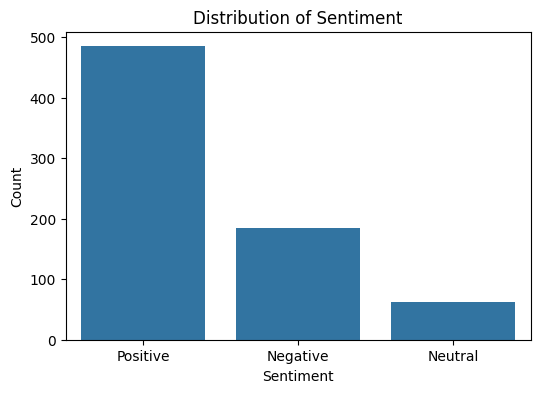

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x="Unified_Sentiment", data=df)

plt.title("Distribution of Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [34]:
# Feature
X = df["Text"]

# Target
y = df["Unified_Sentiment"]

<h3>Encoding Labels</h3>

In [35]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['Negative' 'Neutral' 'Positive']


In [36]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english")

X = vectorizer.fit_transform(X)

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (732, 2389)


<h4>Train - Test - Split</h4>

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (585, 2389)
Testing Shape: (147, 2389)


<h3>Logistic Regression</h3>

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
# Create Logistic Regression model
model = LogisticRegression(random_state=42)

In [47]:
# Train the model
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [48]:
# Predictions on test data
y_pred = model.predict(X_test)

print(y_pred[:10])

[2 2 0 2 2 2 2 2 2 0]


<h3>Evaluation</h3>

In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8027
Precision: 0.7816
Recall   : 0.8027
F1 Score : 0.7711


In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred,
                            target_names=label_encoder.classes_))

              precision    recall  f1-score   support

    Negative       0.83      0.65      0.73        37
     Neutral       0.50      0.08      0.13        13
    Positive       0.80      0.96      0.87        97

    accuracy                           0.80       147
   macro avg       0.71      0.56      0.58       147
weighted avg       0.78      0.80      0.77       147



In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[24,  1, 12],
       [ 1,  1, 11],
       [ 4,  0, 93]])

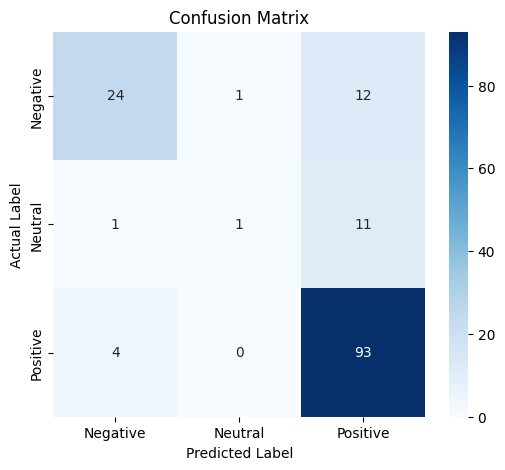

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

<h3>Testing</h3>

In [61]:
test_data = [
    "I absolutely love this product. It is amazing!",
    "The service was terrible and I am very disappointed.",
    "The event was okay, nothing special.",
    "Fantastic customer support and quick delivery.",
    "Worst experience ever. I will never buy again."
]

In [62]:
test_vector = vectorizer.transform(test_data)

In [63]:
predictions = model.predict(test_vector)

predicted_labels = label_encoder.inverse_transform(predictions)

In [64]:
for text, sentiment in zip(test_data, predicted_labels):
    print(f"Text      : {text}")
    print(f"Prediction: {sentiment}")
    print("-" * 60)

Text      : I absolutely love this product. It is amazing!
Prediction: Positive
------------------------------------------------------------
Text      : The service was terrible and I am very disappointed.
Prediction: Negative
------------------------------------------------------------
Text      : The event was okay, nothing special.
Prediction: Positive
------------------------------------------------------------
Text      : Fantastic customer support and quick delivery.
Prediction: Positive
------------------------------------------------------------
Text      : Worst experience ever. I will never buy again.
Prediction: Positive
------------------------------------------------------------


<h3>Saving</h3>

In [65]:
import pickle

# Save Logistic Regression model
with open("logistic_model.pkl", "wb") as file:
    pickle.dump(model, file)

# Save CountVectorizer
with open("vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

# Save Label Encoder
with open("label_encoder.pkl", "wb") as file:
    pickle.dump(label_encoder, file)

print("All files saved successfully!")

All files saved successfully!


In [66]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'label_encoder.pkl', 'Learning Pod B Social Media Sentiment Data - Cleaned_Social_Media_Sentiment_Data.csv', 'logistic_model.pkl', 'Untitled.ipynb', 'vectorizer.pkl']
